In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

X = 2 * np.random.rand(100,1)
noise = np.random.randn(100,1)
y = 4 + 3 * X + noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
def initialize_params():
  w = 0.0
  b = 0.0
  return w, b

def predict(X, w, b):
  return X * w + b

def cost_function(X, y, w, b):
  m = len(y)
  y_pred = predict(X, w, b)
  cost = (1/(2*m)) * np.sum((y_pred - y)**2)
  return cost

def gradient_descent(X, y, w, b, lr, epochs):
  m = len(y)
  loss_history = []
  for i in range(epochs):
    y_pred = predict(X, w, b)
    dw = (1/m) * np.sum((y_pred - y) * X)
    db = (1/m) * np.sum(y_pred - y)
    w -= lr * dw
    b -= lr * db
    loss_history.append(cost_function(X, y, w, b))
  return w, b, loss_history

In [4]:
w, b = initialize_params()
w, b, loss_history = gradient_descent(X_train, y_train, w, b, lr=0.01, epochs=1000)
print(f"Learned w={w:.3f}, b={b:.3f}")

Learned w=2.956, b=3.968


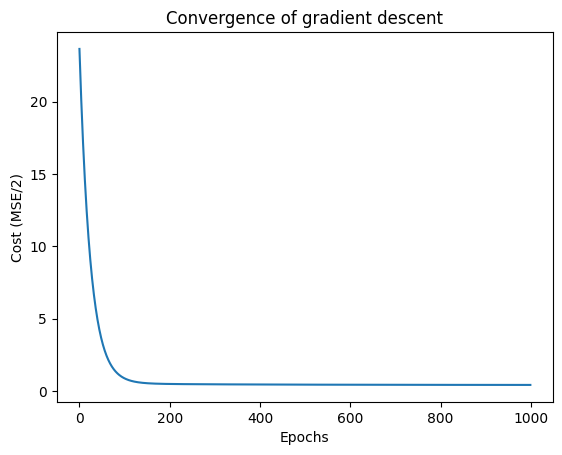

In [5]:
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE/2)")
plt.title("Convergence of gradient descent")
plt.show()

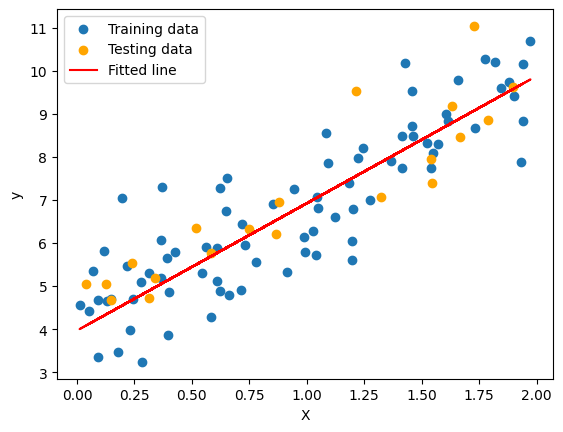

In [6]:
plt.scatter(X_train, y_train, label="Training data")
plt.scatter(X_test, y_test, color='orange', label="Testing data")
plt.plot(X, predict(X, w, b), color='red', label="Fitted line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [7]:
def evaluate(X, y, w, b, label):
  y_pred = predict(X, w, b)
  mae = mean_absolute_error(y, y_pred)
  mse = mean_squared_error(y, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y, y_pred)
  print(f"{label} Results -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

evaluate(X_train, y_train, w, b, "Train")
evaluate(X_test, y_test, w, b, "Test")

Train Results -> MAE: 0.745, MSE: 0.857, RMSE: 0.926, R2: 0.756
Test Results -> MAE: 0.634, MSE: 0.693, RMSE: 0.832, R2: 0.796


**Polynomial** **Regression**

In [10]:
X_poly_train = np.hstack([X_train, X_train**2])
X_poly_test = np.hstack([X_test, X_test**2])

def predict_poly(X, w, b):
  return X @ w + b

def gradient_descent_poly(X, y, w, b, lr, epochs):
  m = len(y)
  for i in range(epochs):
    y_pred = predict_poly(X, w, b)
    dw = (1/m) * X.T @ (y_pred - y)
    db = (1/m) * np.sum(y_pred - y)
    w -= lr * dw
    b -= lr * db
  return w, b

def evaluate_poly(X, y, w, b, label):
  y_pred = predict_poly(X, w, b)
  mae = mean_absolute_error(y, y_pred)
  mse = mean_squared_error(y, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y, y_pred)
  print(f"{label} Results -> MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

w_poly = np.zeros((2,1))
b_poly = 0.0
w_poly, b_poly = gradient_descent_poly(X_poly_train, y_train, w_poly, b_poly, lr=0.01, epochs=1000)
evaluate_poly(X_poly_train, y_train, w_poly, b_poly, "Train")
evaluate_poly(X_poly_test, y_test, w_poly, b_poly, "Test")

Train Results -> MAE: 0.706, MSE: 0.817, RMSE: 0.904, R2: 0.767
Test Results -> MAE: 0.597, MSE: 0.653, RMSE: 0.808, R2: 0.807
